In [69]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sbn

In [70]:
def recursive_search_for_eval_results(root):
    '''Find ``eval/eval_results.csv`` under *root* and stack into one DataFrame.'''
    from pathlib import Path

    root = Path(root)
    csv_paths = sorted(
        path for path in root.rglob('eval_results.csv')
        if path.parent.name == 'eval'
    )
    if not csv_paths:
        return pd.DataFrame()

    frames = [pd.read_csv(path) for path in csv_paths]
    return pd.concat(frames, ignore_index=True, sort=False)



In [71]:
root = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/'

res = recursive_search_for_eval_results(root)
res.head() 

,run_id,config__run_id,config__snakemake_workdir,config__run_n_samples,config__dirs__data,config__dirs__extdata,config__dirs__runs,config__dirs__preds,config__dirs__bio_network,config__dirs__pretrain,...,config__pretrain__init_rna_half_life,config__pretrain__gamma_prior_weight,config__train__gamma_prior_weight,config__node_activity__transform,config__node_activity__mass,config__make_bio_network__function_graph_simplify__enabled,config__make_bio_network__function_graph_simplify__check_reachability,config__make_bio_network__function_graph_simplify__degree_one__enabled,config__make_bio_network__function_graph_simplify__degree_one__in_degree,config__make_bio_network__function_graph_simplify__degree_one__out_degree
0,exp_02,exp_02,NaN,1,/home/exacloud/gscratch/mcweeney_lab/evans/data,../extdata/,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,bionetwork,pretrain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,exp_03,exp_03,NaN,1,/home/exacloud/gscratch/mcweeney_lab/evans/data,../extdata/,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,bionetwork,pretrain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,exp_04,exp_04,NaN,1,/home/exacloud/gscratch/mcweeney_lab/evans/data,../extdata/,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,bionetwork,pretrain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,exp_05,exp_05,NaN,1,/home/exacloud/gscratch/mcweeney_lab/evans/data,../extdata/,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,bionetwork,pretrain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,exp_06,exp_06,NaN,1,/home/exacloud/gscratch/mcweeney_lab/evans/data,../extdata/,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,bionetwork,pretrain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
config_cols = [c for c in res.columns if 'config__' in c]

In [73]:
res[['run_id', 'pretrain__mean_best_val_mse',
 'pretrain__mean_best_val_r2',
 'pretrain__mean_final_val_mse',
 'pretrain__mean_final_val_r2',
 'train__mean_best_val_mse',
 'train__mean_best_val_r2',
 'train__mean_final_val_mse',
 'train__mean_final_val_r2',
]].head() 

,run_id,pretrain__mean_best_val_mse,pretrain__mean_best_val_r2,pretrain__mean_final_val_mse,pretrain__mean_final_val_r2,train__mean_best_val_mse,train__mean_best_val_r2,train__mean_final_val_mse,train__mean_final_val_r2
0,exp_02,0.619533,0.252859,0.619533,0.252859,0.038602,0.297551,0.038602,0.297551
1,exp_03,0.723664,0.159720,0.855172,0.053739,0.030968,0.116166,0.038757,-0.194960
2,exp_04,0.574257,0.221009,0.574257,0.221009,0.028984,0.462189,0.028984,0.462189
3,exp_05,0.630093,0.255007,0.630093,0.255007,0.031834,0.376690,0.031834,0.376690
4,exp_06,0.626005,0.220892,0.835049,0.082417,0.029630,0.142311,0.031974,0.050809


In [74]:
def _col(df, name):
    '''Return column *name* if present, else a NaN series.'''
    if name in df.columns:
        return df[name]
    return pd.Series(np.nan, index=df.index)


def summarize_experiment_results(
    res,
    *,
    source='contrastive',
    path_rank_threshold=5,
    node_mrr_threshold=0.05,
    pvalue_threshold=0.05,
):
    '''Build a per-run summary aligned with the 01a/01b explain notebooks.

    Parameters
    ----------
    res : DataFrame
        Wide eval results from ``recursive_search_for_eval_results``.
    source : str
        Explanation source to score (``contrastive`` matches 01a/01b).
    path_rank_threshold : int
        Expected path counts as prioritized when the best gsnn path rank
        is at or below this value (notebook examples use ranks 1 and 5).
    node_mrr_threshold : float
        Expected nodes count as involved when node-target MRR (gsnn) exceeds
        this value.
    pvalue_threshold : float
        Trajectory AUC contrast is significant below this p-value.
    '''
    import numpy as np

    def _edge(example, suffix):
        return f'{example}__{source}__{suffix}'

    def _node_target(example, suffix):
        return f'{example}_node_target__{source}__{suffix}'

    def _traj(example, suffix):
        return f'{example}__eval_traj_diff__{suffix}'

    summary = pd.DataFrame({'run_id': res['run_id']})

    train_cols = [
        'pretrain__mean_best_val_r2',
        'pretrain__mean_final_val_r2',
        'pretrain__mean_best_val_mse',
        'pretrain__mean_final_val_mse',
        'train__mean_best_val_r2',
        'train__mean_final_val_r2',
        'train__mean_best_val_mse',
        'train__mean_final_val_mse',
    ]
    for col in train_cols:
        summary[col] = _col(res, col)

    # --- Trametinib / DUSP6 (MDAMB231 vs MCF7) ---
    tram = 'trametinib_mapk'
    summary['trametinib__auc_pvalue'] = _col(res, _traj(tram, 'pvalue'))
    summary['trametinib__auc1_MDAMB231'] = _col(res, _traj(tram, 'auc1'))
    summary['trametinib__auc2_MCF7'] = _col(res, _traj(tram, 'auc2'))
    summary['trametinib__auc_diff'] = _col(res, _traj(tram, 'auc_diff'))
    summary['trametinib__auc_significant'] = summary['trametinib__auc_pvalue'] < pvalue_threshold

    summary['trametinib__ets1_gsnn_rank'] = _col(
        res, _edge(tram, 'primary_regulators__PROTEIN__ETS1__gsnn_rank'),
    )
    summary['trametinib__ets1_is_primary_regulator'] = summary['trametinib__ets1_gsnn_rank'] == 1

    summary['trametinib__expected_nodes_mrr_gsnn'] = _col(
        res, _node_target(tram, 'summary_mrr__node__gsnn'),
    )
    summary['trametinib__expected_nodes_involved'] = (
        summary['trametinib__expected_nodes_mrr_gsnn'] >= node_mrr_threshold
    )

    summary['trametinib__expected_edges_mrr_gsnn'] = _col(
        res, _edge(tram, 'summary_mrr__edge__gsnn'),
    )
    summary['trametinib__path_mrr_gsnn'] = _col(
        res, _edge(tram, 'summary_mrr__path__mean_gsnn_score_product'),
    )

    tram_path_cols = [
        _edge(tram, 'path_ranking_ranks__MAP2K1_to_MAPK3_to_ETS1_to_DUSP6__mean_gsnn_score_product_rank'),
        _edge(tram, 'path_ranking_ranks__MAP2K2_to_MAPK3_to_ETS1_to_DUSP6__mean_gsnn_score_product_rank'),
    ]
    tram_path_ranks = pd.concat([_col(res, c) for c in tram_path_cols], axis=1)
    summary['trametinib__best_expected_path_gsnn_rank'] = tram_path_ranks.min(axis=1)
    summary['trametinib__expected_paths_prioritized'] = (
        summary['trametinib__best_expected_path_gsnn_rank'] <= path_rank_threshold
    )

    # --- Palbociclib / CCNA2 (T47D vs MDAMB468) ---
    palb = 'palbociclib_ccna2'
    summary['palbociclib__auc_pvalue'] = _col(res, _traj(palb, 'pvalue'))
    summary['palbociclib__auc1_T47D'] = _col(res, _traj(palb, 'auc1'))
    summary['palbociclib__auc2_MDAMB468'] = _col(res, _traj(palb, 'auc2'))
    summary['palbociclib__auc_diff'] = _col(res, _traj(palb, 'auc_diff'))
    summary['palbociclib__auc_significant'] = summary['palbociclib__auc_pvalue'] < pvalue_threshold

    summary['palbociclib__e2f1_gsnn_rank'] = _col(
        res, _edge(palb, 'primary_regulators__PROTEIN__E2F1__gsnn_rank'),
    )
    summary['palbociclib__e2f1_is_primary_regulator'] = summary['palbociclib__e2f1_gsnn_rank'] == 1

    summary['palbociclib__expected_nodes_mrr_gsnn'] = _col(
        res, _node_target(palb, 'summary_mrr__node__gsnn'),
    )
    summary['palbociclib__expected_nodes_involved'] = (
        summary['palbociclib__expected_nodes_mrr_gsnn'] >= node_mrr_threshold
    )

    summary['palbociclib__expected_edges_mrr_gsnn'] = _col(
        res, _edge(palb, 'summary_mrr__edge__gsnn'),
    )
    summary['palbociclib__path_mrr_gsnn'] = _col(
        res, _edge(palb, 'summary_mrr__path__mean_gsnn_score_product'),
    )

    palb_path_cols = [
        _edge(palb, 'path_ranking_ranks__CDK4_to_RB1_to_E2F1_to_CCNA2__mean_gsnn_score_product_rank'),
        _edge(palb, 'path_ranking_ranks__CDK6_to_RB1_to_E2F1_to_CCNA2__mean_gsnn_score_product_rank'),
    ]
    palb_path_ranks = pd.concat([_col(res, c) for c in palb_path_cols], axis=1)
    summary['palbociclib__best_expected_path_gsnn_rank'] = palb_path_ranks.min(axis=1)
    summary['palbociclib__expected_paths_prioritized'] = (
        summary['palbociclib__best_expected_path_gsnn_rank'] <= path_rank_threshold
    )

    # Composite scores (higher is better).
    train_r2 = summary[['pretrain__mean_best_val_r2', 'train__mean_best_val_r2']].mean(axis=1)

    tram_checks = summary[[
        'trametinib__auc_significant',
        'trametinib__ets1_is_primary_regulator',
        'trametinib__expected_nodes_involved',
        'trametinib__expected_paths_prioritized',
    ]].astype(float)

    palb_checks = summary[[
        'palbociclib__auc_significant',
        'palbociclib__e2f1_is_primary_regulator',
        'palbociclib__expected_nodes_involved',
        'palbociclib__expected_paths_prioritized',
    ]].astype(float)

    summary['explanation_score_trametinib'] = tram_checks.mean(axis=1)
    summary['explanation_score_palbociclib'] = palb_checks.mean(axis=1)
    summary['explanation_score'] = (tram_checks.mean(axis=1) + palb_checks.mean(axis=1)) / 2
    summary['overall_score'] = 0.5 * train_r2 + 0.5 * summary['explanation_score']

    return summary


In [75]:
summary_df = summarize_experiment_results(res)
summary_df.sort_values('overall_score', ascending=False)


,run_id,pretrain__mean_best_val_r2,pretrain__mean_final_val_r2,pretrain__mean_best_val_mse,pretrain__mean_final_val_mse,train__mean_best_val_r2,train__mean_final_val_r2,train__mean_best_val_mse,train__mean_final_val_mse,trametinib__auc_pvalue,...,palbociclib__expected_nodes_mrr_gsnn,palbociclib__expected_nodes_involved,palbociclib__expected_edges_mrr_gsnn,palbociclib__path_mrr_gsnn,palbociclib__best_expected_path_gsnn_rank,palbociclib__expected_paths_prioritized,explanation_score_trametinib,explanation_score_palbociclib,explanation_score,overall_score
10,exp_14,0.414118,0.414118,0.451107,0.451107,0.521715,5.218832e-01,0.020283,2.030314e-02,0.160752,...,0.068729,True,0.007757,0.087558,7.0,False,0.50,0.50,0.500,0.483958
5,exp_08,0.359216,0.354932,0.524287,0.530459,0.494763,4.947628e-01,0.022134,2.213434e-02,0.031255,...,0.027318,False,0.000792,0.055060,16.0,False,1.00,0.00,0.500,0.463495
19,exp_27,0.498899,0.498899,0.390372,0.390372,NaN,NaN,NaN,NaN,NaN,...,0.272341,True,0.012775,0.562500,1.0,True,0.25,0.50,0.375,0.436949
20,exp_28,0.494504,0.494504,0.379802,0.379802,NaN,NaN,NaN,NaN,NaN,...,0.058561,True,0.008447,0.109890,7.0,False,0.25,0.50,0.375,0.434752
6,exp_10,0.429610,0.429698,0.427744,0.428214,0.488021,4.880215e-01,0.021851,2.185083e-02,0.023222,...,0.020855,False,0.004431,0.085227,8.0,False,0.50,0.25,0.375,0.416908
8,exp_12,0.397426,0.398396,0.461432,0.468502,0.497426,4.974257e-01,0.022629,2.262927e-02,0.055594,...,0.058519,True,0.000604,0.042232,17.0,False,0.50,0.25,0.375,0.411213
2,exp_04,0.221009,0.221009,0.574257,0.574257,0.462189,4.621889e-01,0.028984,2.898357e-02,NaN,...,0.003087,False,0.000823,0.052564,15.0,False,0.75,0.00,0.375,0.358300
7,exp_11,0.398343,0.382576,0.470963,0.480206,0.493673,4.936734e-01,0.021730,2.173022e-02,0.028027,...,0.029004,False,0.007444,0.023634,34.0,False,0.50,0.00,0.250,0.348004
9,exp_13,0.408286,0.408286,0.480459,0.480459,0.469193,4.691927e-01,0.024137,2.413749e-02,0.052741,...,0.017069,False,0.006135,0.026546,31.0,False,0.50,0.00,0.250,0.344370
12,exp_16,0.344854,0.344854,0.501735,0.501735,0.524997,5.235578e-01,0.020282,2.034897e-02,0.231538,...,0.032554,False,0.035355,0.027047,36.0,False,0.25,0.25,0.250,0.342463


In [76]:
# Compact view for model comparison
summary_df[[
    'run_id',
    'pretrain__mean_best_val_r2',
    'train__mean_best_val_r2',
    'trametinib__auc_pvalue',
    'trametinib__ets1_is_primary_regulator',
    'trametinib__expected_nodes_involved',
    'trametinib__expected_paths_prioritized',
    'palbociclib__auc_pvalue',
    'palbociclib__e2f1_is_primary_regulator',
    'palbociclib__expected_nodes_involved',
    'palbociclib__expected_paths_prioritized',
    'explanation_score',
    'overall_score',
]].sort_values('overall_score', ascending=False)


,run_id,pretrain__mean_best_val_r2,train__mean_best_val_r2,trametinib__auc_pvalue,trametinib__ets1_is_primary_regulator,trametinib__expected_nodes_involved,trametinib__expected_paths_prioritized,palbociclib__auc_pvalue,palbociclib__e2f1_is_primary_regulator,palbociclib__expected_nodes_involved,palbociclib__expected_paths_prioritized,explanation_score,overall_score
10,exp_14,0.414118,0.521715,0.160752,False,True,True,0.038618,False,True,False,0.500,0.483958
5,exp_08,0.359216,0.494763,0.031255,True,True,True,0.179468,False,False,False,0.500,0.463495
19,exp_27,0.498899,NaN,NaN,False,True,False,NaN,False,True,True,0.375,0.436949
20,exp_28,0.494504,NaN,NaN,False,True,False,NaN,True,True,False,0.375,0.434752
6,exp_10,0.429610,0.488021,0.023222,False,True,False,0.028180,False,False,False,0.375,0.416908
8,exp_12,0.397426,0.497426,0.055594,False,True,True,0.202207,False,True,False,0.375,0.411213
2,exp_04,0.221009,0.462189,NaN,True,True,True,NaN,False,False,False,0.375,0.358300
7,exp_11,0.398343,0.493673,0.028027,False,True,False,0.669444,False,False,False,0.250,0.348004
9,exp_13,0.408286,0.469193,0.052741,False,True,True,0.166895,False,False,False,0.250,0.344370
12,exp_16,0.344854,0.524997,0.231538,False,True,False,0.017158,False,False,False,0.250,0.342463


In [77]:
summary_df[lambda x: (x['trametinib__auc_pvalue'] < 0.25) 
        & (x['palbociclib__auc_pvalue'] < 0.25)
        & (x['trametinib__ets1_is_primary_regulator'] == True)
        & (x['palbociclib__e2f1_is_primary_regulator'] == True)][[
    'trametinib__ets1_is_primary_regulator',
    'trametinib__expected_nodes_involved',
    'trametinib__expected_paths_prioritized',
    'palbociclib__e2f1_is_primary_regulator',
    'palbociclib__expected_nodes_involved',
    'palbociclib__expected_paths_prioritized',
    'explanation_score',]]

,trametinib__ets1_is_primary_regulator,trametinib__expected_nodes_involved,trametinib__expected_paths_prioritized,palbociclib__e2f1_is_primary_regulator,palbociclib__expected_nodes_involved,palbociclib__expected_paths_prioritized,explanation_score


In [78]:
summary_df[['run_id',
    'pretrain__mean_best_val_r2',
    'train__mean_best_val_r2',
    'explanation_score',
    'overall_score',]].sort_values('overall_score', ascending=False)

,run_id,pretrain__mean_best_val_r2,train__mean_best_val_r2,explanation_score,overall_score
10,exp_14,0.414118,0.521715,0.500,0.483958
5,exp_08,0.359216,0.494763,0.500,0.463495
19,exp_27,0.498899,NaN,0.375,0.436949
20,exp_28,0.494504,NaN,0.375,0.434752
6,exp_10,0.429610,0.488021,0.375,0.416908
8,exp_12,0.397426,0.497426,0.375,0.411213
2,exp_04,0.221009,0.462189,0.375,0.358300
7,exp_11,0.398343,0.493673,0.250,0.348004
9,exp_13,0.408286,0.469193,0.250,0.344370
12,exp_16,0.344854,0.524997,0.250,0.342463


In [79]:
config_counts = pd.Series([res[c].nunique() for c in config_cols], index=config_cols)
config_counts = config_counts[lambda x: x >= 2]

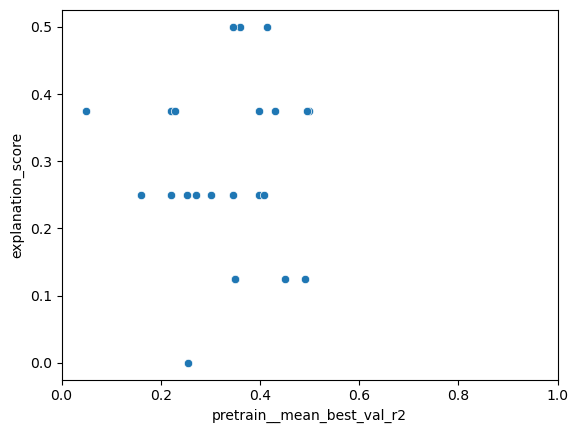

In [80]:
plt.figure() 
sbn.scatterplot(x='pretrain__mean_best_val_r2', y='explanation_score', data=summary_df)
plt.xlim(0,1)
plt.show() 


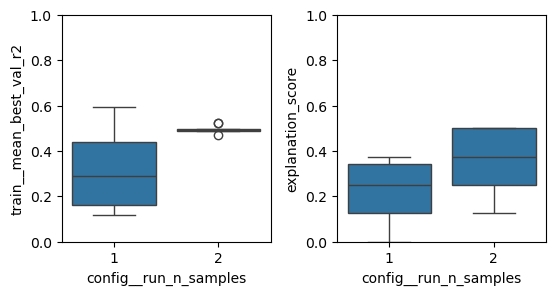

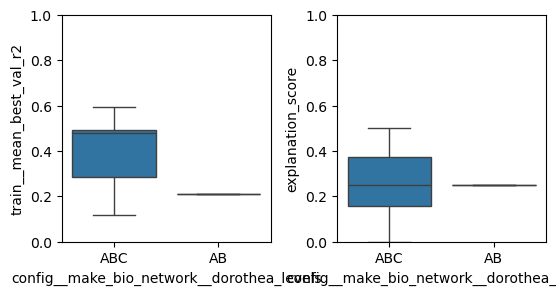

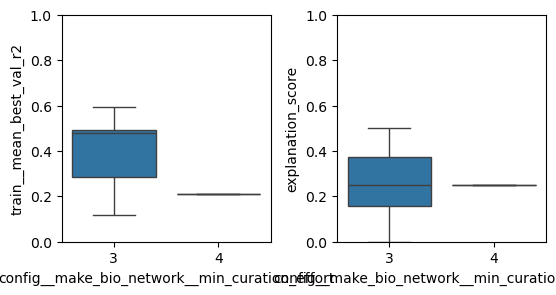

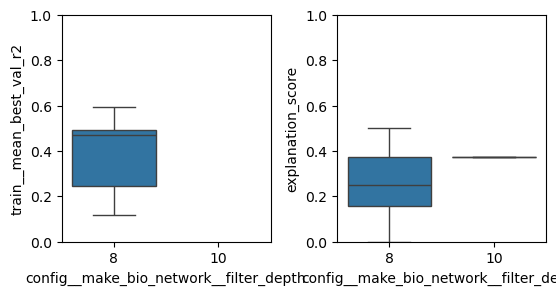

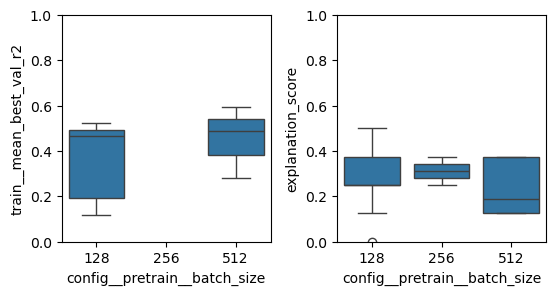

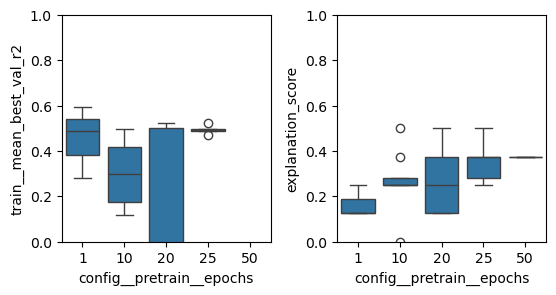

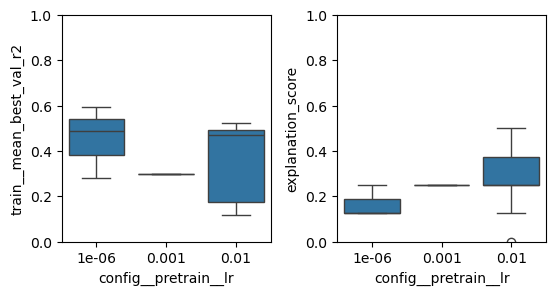

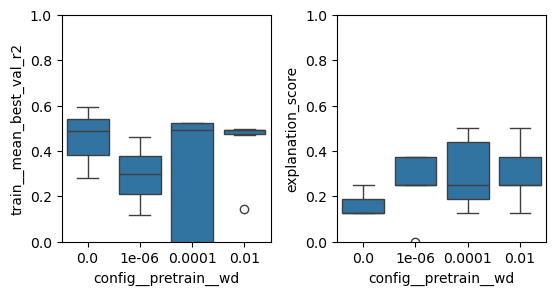

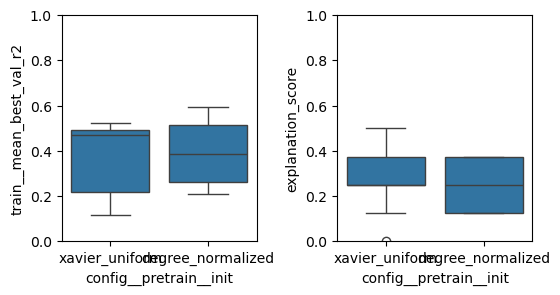

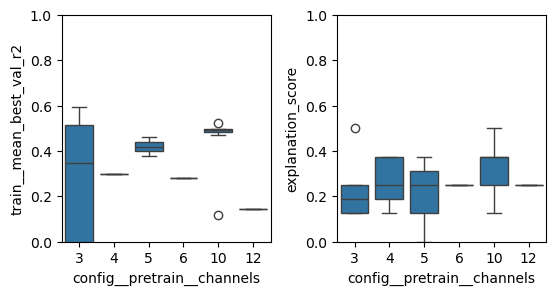

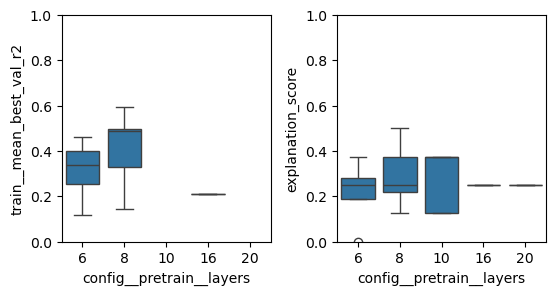

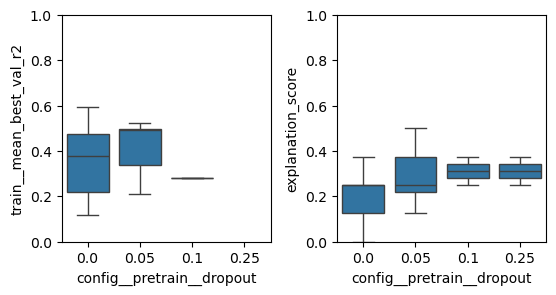

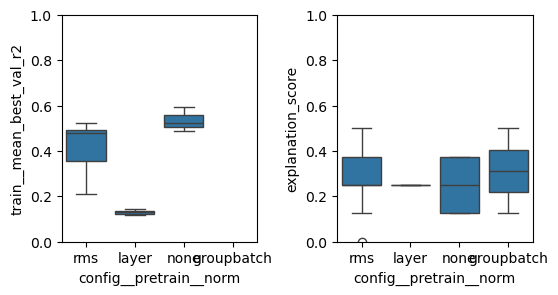

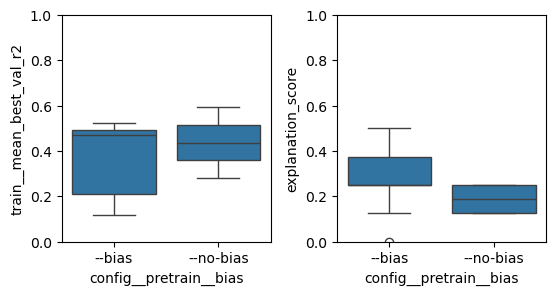

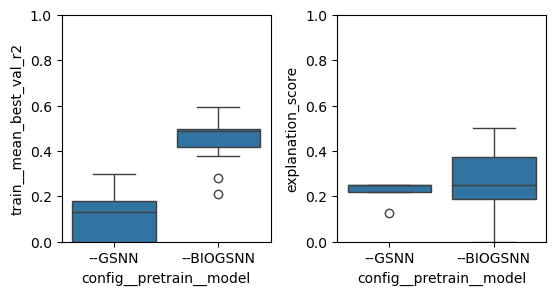

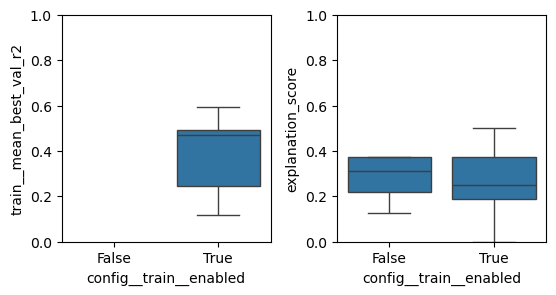

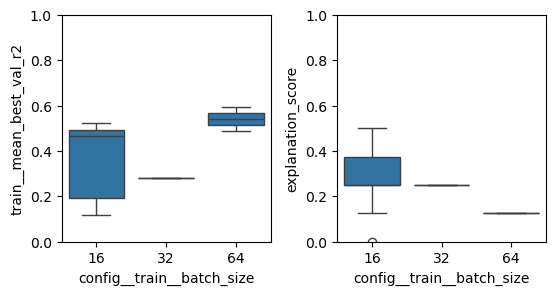

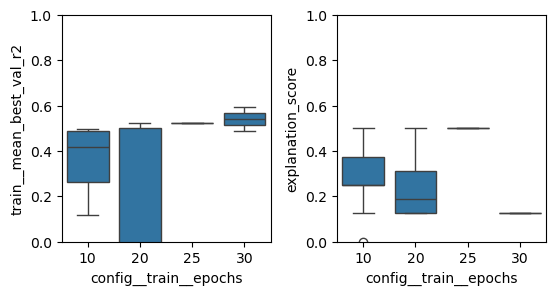

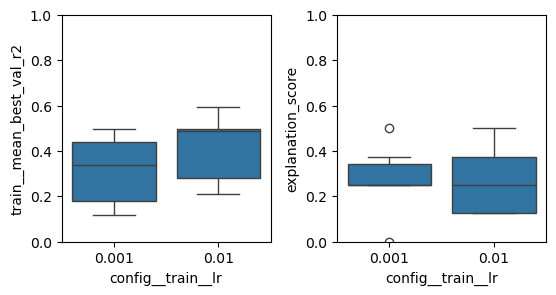

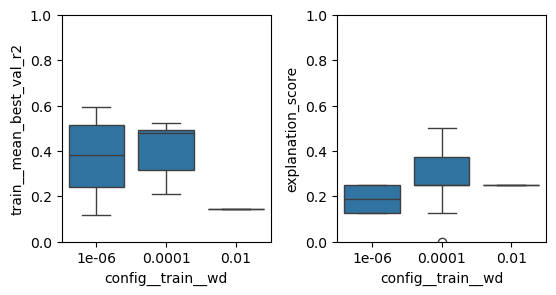

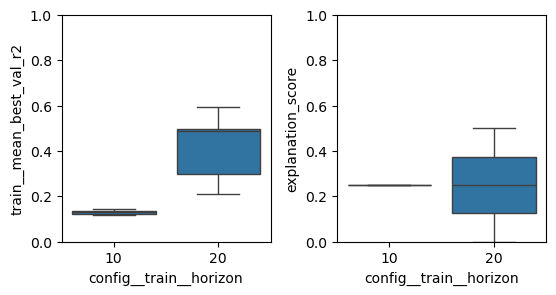

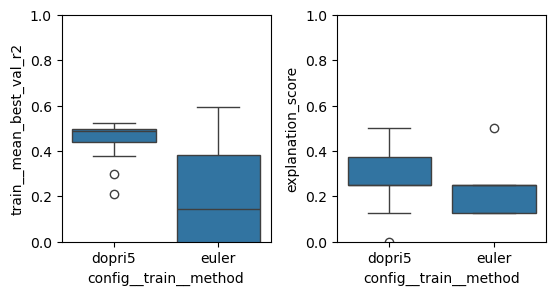

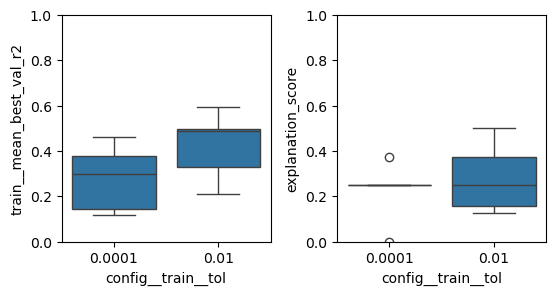

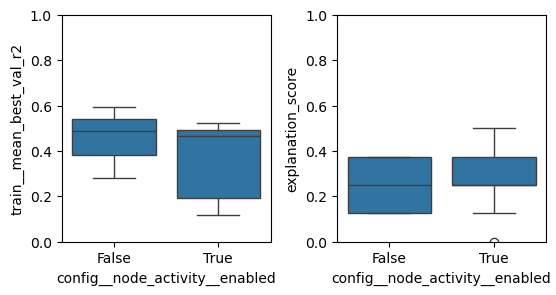

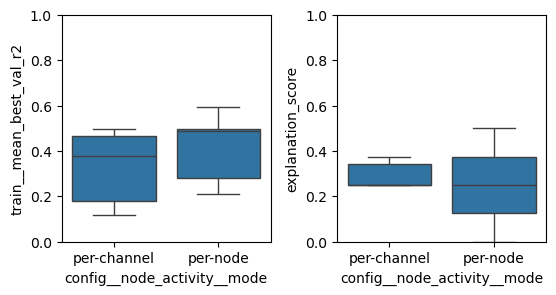

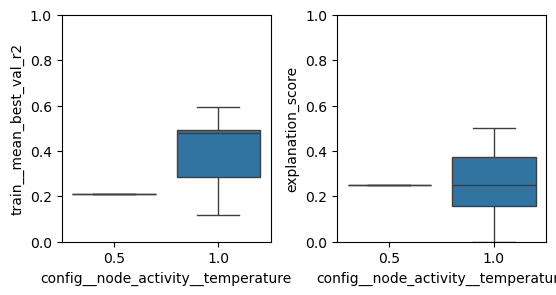

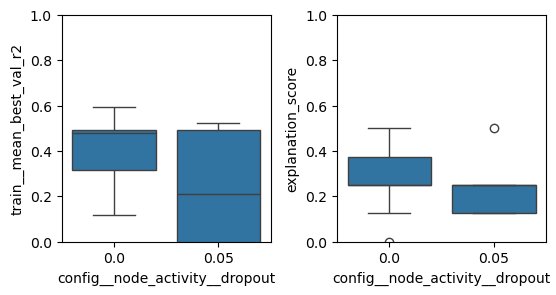

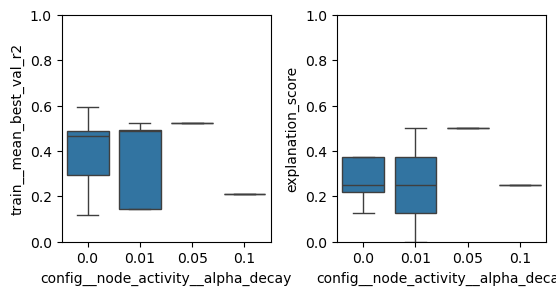

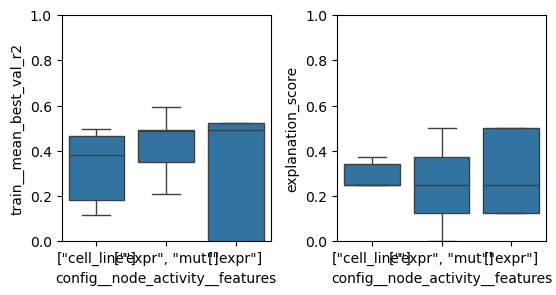

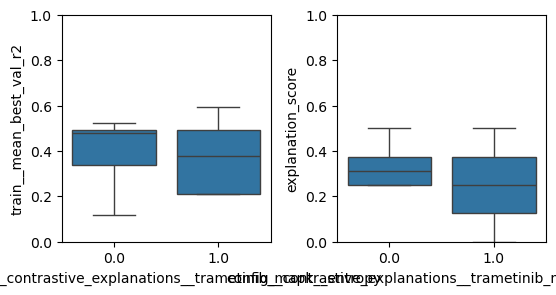

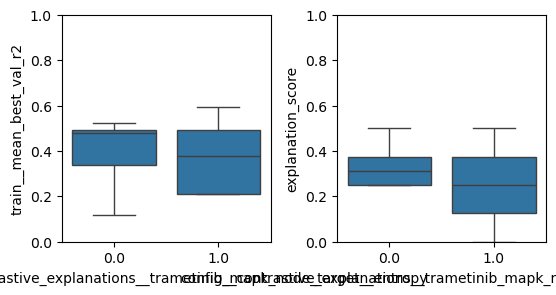

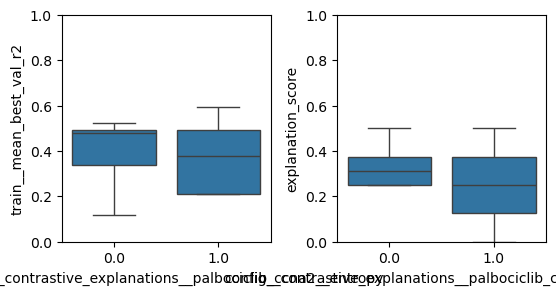

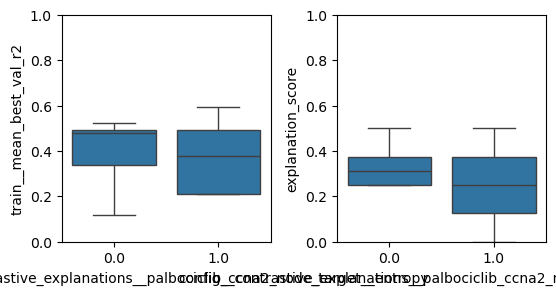

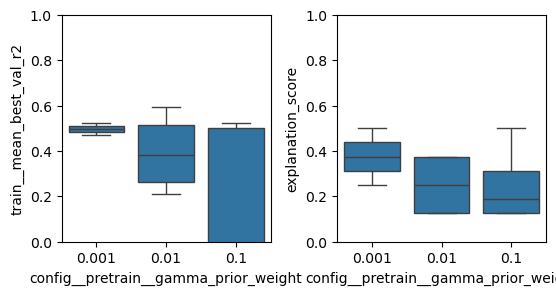

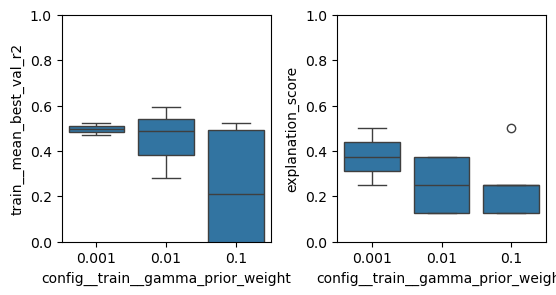

In [81]:


for config_col in config_counts.index[1:]: 
    f,axes = plt.subplots(1, 2, figsize=(6, 3))
    sbn.boxplot(x=config_col, y='train__mean_best_val_r2', data=summary_df.merge(res, on=['run_id', 'train__mean_best_val_r2']), ax=axes[0])
    sbn.boxplot(x=config_col, y='explanation_score', data=summary_df.merge(res, on=['run_id', 'train__mean_best_val_r2']), ax=axes[1])
    plt.tight_layout()
    axes[0].set_ylim(0,1)
    axes[1].set_ylim(0,1)
    plt.show() 


## GP + Expected Improvement for `train__mean_best_val_r2`

Fits a Gaussian process surrogate over the encoded hyperparameter design matrix and ranks unseen Cartesian-product configurations (over observed levels of each hyperparameter) by Expected Improvement. With ~10 observed runs treat absolute EI values as a heuristic; use the ordering and the per-hyperparameter EI plot to choose the next config to launch.

In [82]:
from lincs_gsnn.explain.reg import (
    encode_config_frame,
    enumerate_observed_grid,
    fit_gp_surrogate,
    param_specs_table,
    plot_ei_marginal,
    plot_gp_diagnostics,
    prepare_regression_frame,
    propose_next_configs,
    rank_candidates_by_ei,
    select_varying_config_columns,
)

TARGET = 'explanation_score' #'train__mean_best_val_r2'

reg_frame = prepare_regression_frame(res, summary_df, target=TARGET)
param_cols, param_meta = select_varying_config_columns(reg_frame)
print(f'Regression N={len(reg_frame)} runs, {len(param_cols)} varying hyperparameters')
param_meta

Regression N=19 runs, 39 varying hyperparameters


,param,short_name,n_unique,kind,example_values
0,config__make_bio_network__dorothea_levels,make_bio_network_dorothea_levels,2,binary,"[ABC, AB]"
1,config__make_bio_network__include_collecTRI,make_bio_network_include_collecTRI,2,categorical,[--include_collecTRI]
2,config__make_bio_network__include_tf_mirna,make_bio_network_include_tf_mirna,2,categorical,[--include_tf_mirna]
3,config__make_bio_network__min_curation_effort,make_bio_network_min_curation_effort,2,numeric,"[3, 4]"
4,config__make_bio_network__min_n_references,make_bio_network_min_n_references,2,boolean,[0.0]
5,config__node_activity__alpha_decay,node_activity_alpha_decay,4,numeric,"[0.0, 0.01, 0.05, 0.1]"
6,config__node_activity__dropout,node_activity_dropout,2,numeric,"[0.0, 0.05]"
7,config__node_activity__enabled,node_activity_enabled,2,boolean,"[True, False]"
8,config__node_activity__features,node_activity_features,3,json_list,"[[""cell_line""], [""expr"", ""mut""], [""expr""]]"
9,config__node_activity__mass,node_activity_mass,2,numeric,[2000.0]


In [83]:
encoded = encode_config_frame(reg_frame, param_cols)
search_space = param_specs_table(encoded)
search_space

,param,kind,n_unique,observed_values,encoded_columns,categories,lower,upper,log_transform
0,config__make_bio_network__dorothea_levels,binary,2,"[ABC, AB]",[make_bio_network_dorothea_levels],"[ABC, AB]",NaN,NaN,NaN
1,config__make_bio_network__include_collecTRI,categorical,1,[--include_collecTRI],[make_bio_network_include_collecTRI_nan],"[--include_collecTRI, nan]",NaN,NaN,NaN
2,config__make_bio_network__include_tf_mirna,categorical,1,[--include_tf_mirna],[make_bio_network_include_tf_mirna_nan],"[--include_tf_mirna, nan]",NaN,NaN,NaN
3,config__make_bio_network__min_curation_effort,numeric,2,"[3, 4]",[make_bio_network_min_curation_effort],NaN,3.000,4.00,NaN
4,config__make_bio_network__min_n_references,boolean,1,[0.0],[make_bio_network_min_n_references],[0.0],NaN,NaN,NaN
5,config__node_activity__alpha_decay,numeric,4,"[0.0, 0.01, 0.05, 0.1]",[node_activity_alpha_decay__log10],NaN,-2.000,-1.00,True
6,config__node_activity__dropout,numeric,2,"[0.0, 0.05]",[node_activity_dropout],NaN,0.000,0.05,NaN
7,config__node_activity__enabled,boolean,2,"[True, False]",[node_activity_enabled],"[True, False]",NaN,NaN,NaN
8,config__node_activity__features,json_list,3,"[[""cell_line""], [""expr"", ""mut""], [""expr""]]","[node_activity_features__has_expr, node_activi...","[has_expr, has_mut, has_cell_line]",NaN,NaN,NaN
9,config__node_activity__mass,numeric,1,[2000.0],[node_activity_mass],NaN,2000.000,2000.00,NaN


In [84]:
gp_result = fit_gp_surrogate(reg_frame, param_cols, target=TARGET)
print('Kernel:', gp_result.kernel_)
print(f'LOO R^2: {gp_result.loo_r2:.3f}  (n={len(gp_result.y_train)})')

/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to t

Kernel: 0.949**2 * Matern(length_scale=0.012, nu=2.5) + WhiteKernel(noise_level=0.0993)
LOO R^2: -0.050  (n=19)


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


<Figure size 500x500 with 0 Axes>

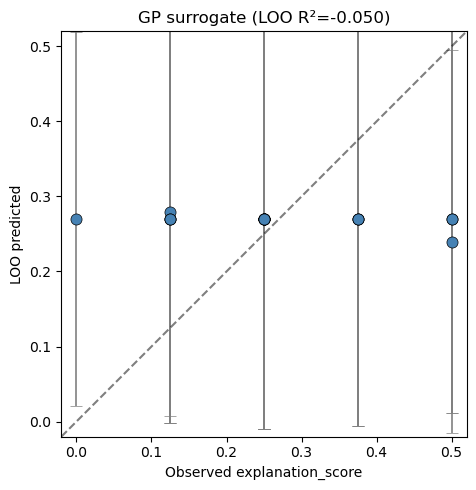

In [85]:
plt.figure(figsize=(5, 5))
plot_gp_diagnostics(gp_result)
plt.tight_layout()
plt.show()

In [86]:
gp_result, ranking = propose_next_configs(
    reg_frame, param_cols, target=TARGET, xi=0.01,
)
print(
    f'Grid search over {len(ranking.attrs.get("grid_param_cols", []))} hyperparameters '
    f'({ranking.attrs.get("grid_size", 0):,} observed combinations)'
)
ranking.head(20)

/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to t

Grid search over 16 hyperparameters (98,304 observed combinations)


,ei,mu,sigma,mu_minus_best,make_bio_network_dorothea_levels,make_bio_network_min_curation_effort,node_activity_dropout,node_activity_enabled,node_activity_features,node_activity_mode,node_activity_temperature,pretrain_batch_size,pretrain_bias,pretrain_init,pretrain_model,run_n_samples,train_horizon,train_lr,train_method,train_tol
0,0.002119,0.269737,0.136106,-0.230263,AB,4,0.05,False,"[""expr""]",per-node,0.5,512,--no-bias,degree_normalized,--BIOGSNN,2,10,0.010,euler,0.0100
1,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr"", ""mut""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,dopri5,0.0001
2,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,dopri5,0.0001
3,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""cell_line""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,dopri5,0.0100
4,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr"", ""mut""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,dopri5,0.0100
5,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,dopri5,0.0100
6,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""cell_line""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,euler,0.0001
7,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr"", ""mut""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,euler,0.0001
8,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""expr""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,euler,0.0001
9,0.002119,0.269737,0.136106,-0.230263,ABC,3,0.00,True,"[""cell_line""]",per-channel,1.0,128,--bias,xavier_uniform,--GSNN,1,20,0.001,euler,0.0100


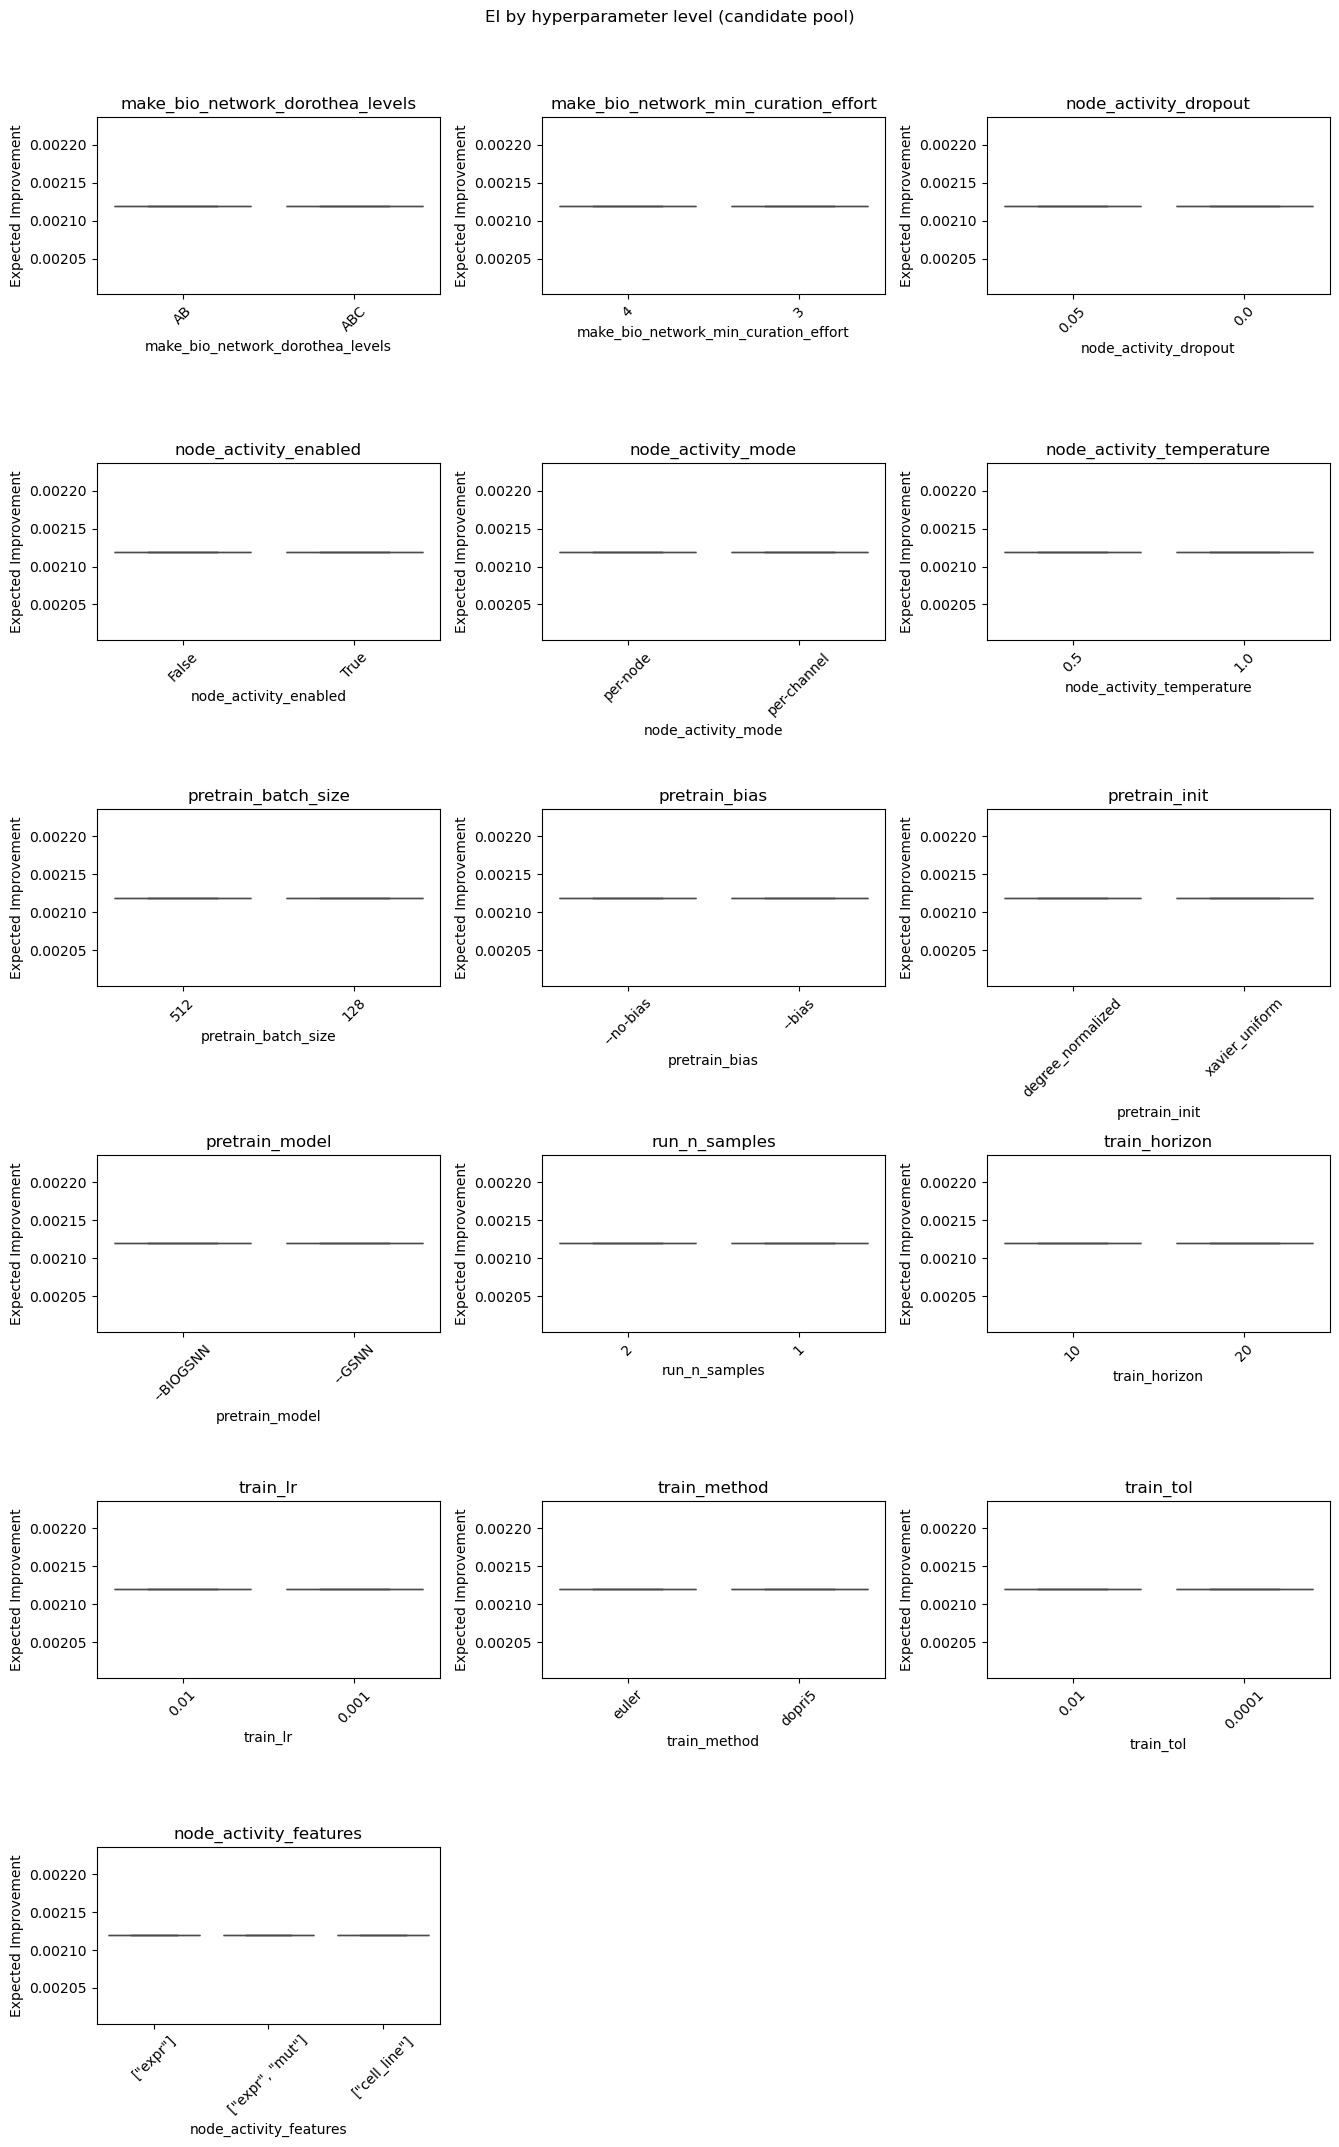

In [87]:
grid_cols = ranking.attrs.get('grid_param_cols', param_cols)
plot_ei_marginal(ranking, grid_cols)
plt.tight_layout()
plt.show()